In [1]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt

In [20]:
frame='145A_05152_131313'
# Get daz correction (azimuth ionospheric delay)
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

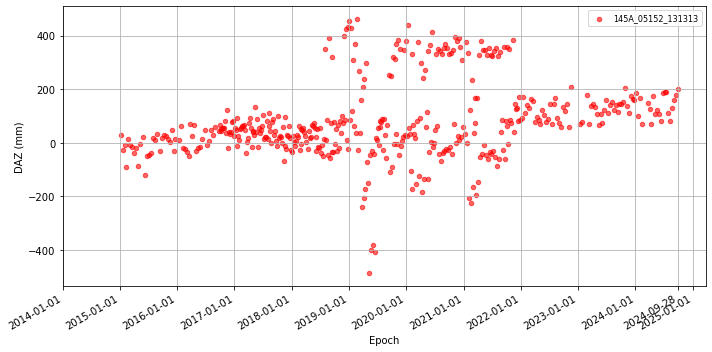

In [21]:
import matplotlib.dates as mdates
# Plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], dazes['daz'], color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Defau ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
# fig.savefig(f"{frame}_daz_plot.png", dpi=150)
plt.show()

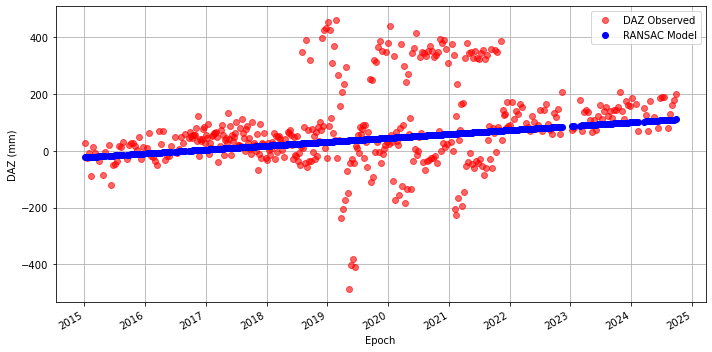

In [22]:
from sklearn.linear_model import RANSACRegressor, LinearRegression
# Convert epoch to numeric time in days
df_daz=dazes.copy()
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)  # model prediction for all dates

# Plot DAZ and DAZ model
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_daz['epoch'], df_daz['daz'], 'o', color='red', alpha=0.6, label='DAZ Observed')
if 'daz_model' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_model'], 'o', color='blue', label='RANSAC Model')

ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

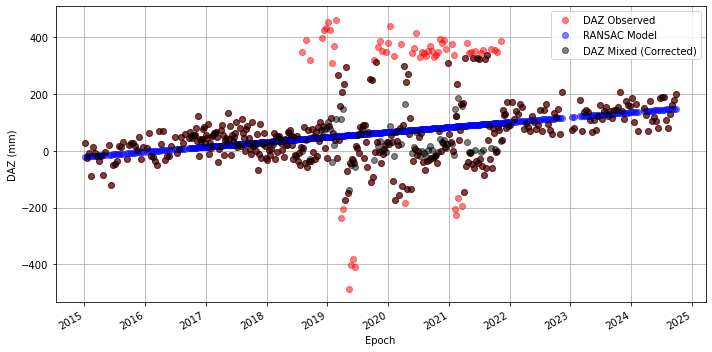

In [26]:
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.pyplot as plt

# Convert epoch to numeric time in days
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
    df_daz['daz_mixed'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)

    # Replace DAZ values with model if the difference > threshold (250 mm)
    # threshold = 250
    # diff = np.abs(df_daz['daz'] - df_daz['daz_model'])
    # df_daz['daz_mixed'] = np.where(diff > threshold, df_daz['daz_model'], df_daz['daz'])
    threshold = 250
    adjustment = 350
    diff = np.abs(df_daz['daz'] - df_daz['daz_model'])
    
    df_daz['daz_mixed'] = df_daz['daz']  # initialize with original values
    
    # Apply custom correction
    mask_large_diff = diff > threshold
    df_daz.loc[mask_large_diff & (df_daz['daz'] > df_daz['daz_model']), 'daz_mixed'] -= adjustment
    df_daz.loc[mask_large_diff & (df_daz['daz'] < df_daz['daz_model']), 'daz_mixed'] += adjustment
    

    

# Plot DAZ (original), model, and mixed
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_daz['epoch'], df_daz['daz'], 'o', color='red', alpha=0.5, label='DAZ Observed')
if 'daz_model' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_model'], 'o', color='blue', alpha=0.5, label='RANSAC Model')
if 'daz_mixed' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_mixed'], 'o', color='black', alpha=0.5,label='DAZ Mixed (Corrected)')

ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [13]:
390-39

351

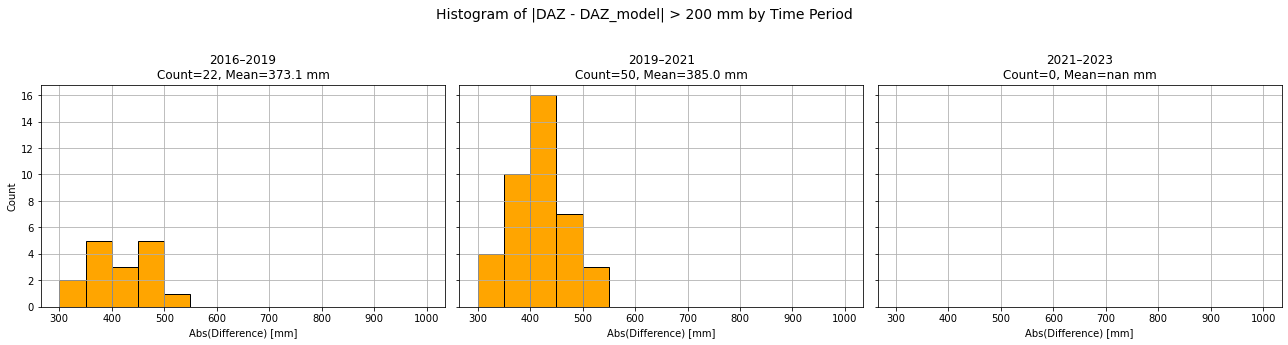

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression

# Convert epoch to numeric time in days
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
    df_daz['daz_mixed'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)

    # Replace DAZ values with model if the difference > threshold (250 mm)
    threshold = 250
    diff = np.abs(df_daz['daz'] - df_daz['daz_model'])
    df_daz['daz_mixed'] = np.where(diff > threshold, df_daz['daz_model'], df_daz['daz'])
    df_daz['diff'] = diff

    # Filter bins for values > 200 mm only
    bins = np.arange(300, 1001, 50)  # bins start from 200 mm

    fig_hist, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    periods = [
        ('2016-01-01', '2018-12-31', '2016–2019'),
        ('2019-01-01', '2020-12-31', '2019–2021'),
        ('2021-01-01', '2022-12-31', '2021–2023')
    ]

    for i, (start, end, label) in enumerate(periods):
        mask_period = (df_daz['epoch'] >= start) & (df_daz['epoch'] <= end)
        diff_subset = df_daz.loc[mask_period & (df_daz['diff'] > 200), 'diff']
        
        axs[i].hist(diff_subset, bins=bins, color='orange', edgecolor='black')
        axs[i].set_title(f'{label}\nCount={len(diff_subset)}, Mean={diff_subset.mean():.1f} mm')
        axs[i].set_xlabel('Abs(Difference) [mm]')
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel('Count')

    fig_hist.suptitle('Histogram of |DAZ - DAZ_model| > 200 mm by Time Period', fontsize=14)
    fig_hist.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
